In [9]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from scipy import stats

In [10]:
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

## Stage 1: Data loading & first inspection

In [11]:
df = pd.read_csv("../data/raw/Telco_Data.csv")

In [12]:
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nMemory: {df.memory_usage(deep=True).sum() / 1024:.1f} KB")

Shape: (7043, 21)
Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Memory: 7975.1 KB


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
print("Numerical Values:")
display(df.describe())

Numerical Values:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


In [16]:
print("Categorical Values:")
display(df.describe(include = "object" ))

Categorical Values:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


### Findings from Stage 1
- Shape is (7043, 21), manageable, no chunking needed
- `TotalCharges` dtype is `object`, should be float.
- `SeniorCitizen` is `int64` but is logically binary categorical (0/1)
- `customerID` is a string identifier, not a feature, will be dropped
- No immediate impossible values in numerical ranges (tenure 0–72, charges look reasonable)

## Stage 2: Target variable analysis

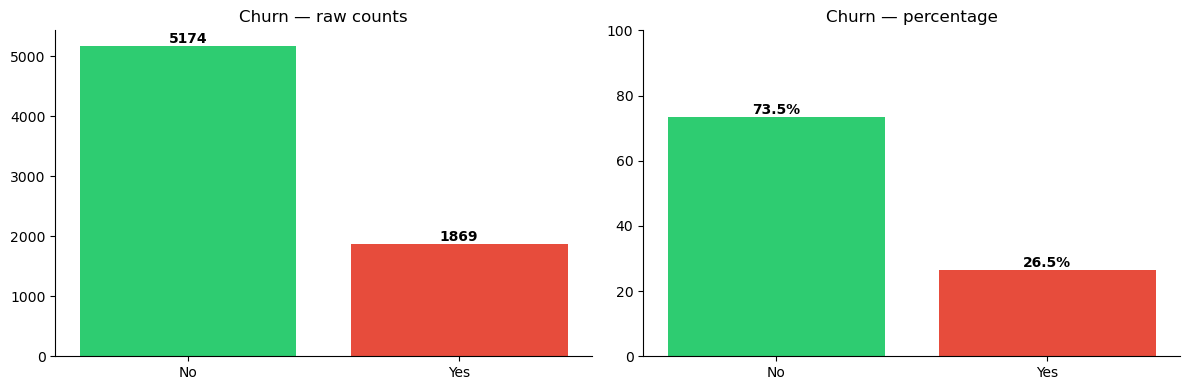

Churn rate: 26.5%
Class ratio (No:Yes): 2.8:1


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

# Raw counts
axes[0].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn — raw counts')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Percentages
axes[1].bar(churn_pct.index, churn_pct.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Churn — percentage')
axes[1].set_ylim(0, 100)
for i, v in enumerate(churn_pct.values):
    axes[1].text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Churn rate: {churn_pct['Yes']:.1f}%")
print(f"Class ratio (No:Yes): {churn_counts['No']/churn_counts['Yes']:.1f}:1")

### Findings from Stage 2
- Churn rate is 26.5%, moderately imbalanced (~2.7:1 ratio)
- This means accuracy is a misleading metric.
- We will use **AUC-ROC** and **precision-recall** as primary metrics.
- Class imbalance is not severe enough to require SMOTE.

## Stage 3: Univariate EDA

### Numerical distributions

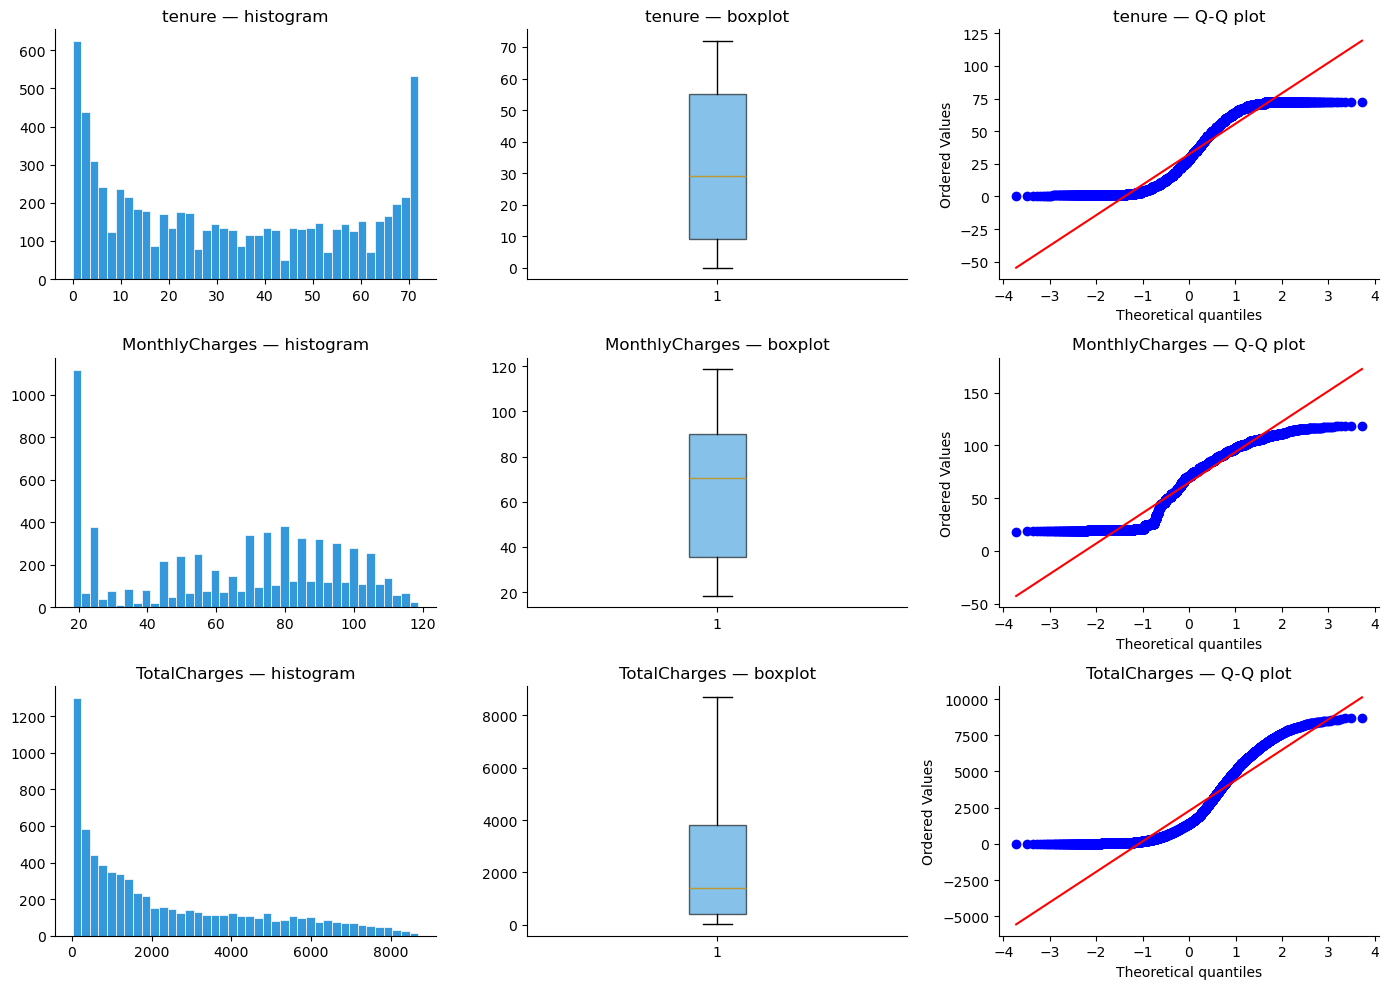

In [18]:
df_plot = df.copy()
df_plot['TotalCharges'] = pd.to_numeric(df_plot['TotalCharges'], errors='coerce')
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(3, 3, figsize=(14, 10))

for i, col in enumerate(num_cols):
    data = df_plot[col].dropna()

    # Histogram
    axes[i, 0].hist(data, bins=40, color='#3498db', edgecolor='white', linewidth=0.5)
    axes[i, 0].set_title(f'{col} — histogram')

    # Boxplot
    axes[i, 1].boxplot(data, patch_artist=True,
                       boxprops=dict(facecolor='#3498db', alpha=0.6))
    axes[i, 1].set_title(f'{col} — boxplot')

    # Q-Q plot 
    stats.probplot(data, dist='norm', plot=axes[i, 2])
    axes[i, 2].set_title(f'{col} — Q-Q plot')

plt.tight_layout()
plt.savefig('../reports/02_numerical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Categorical value counts

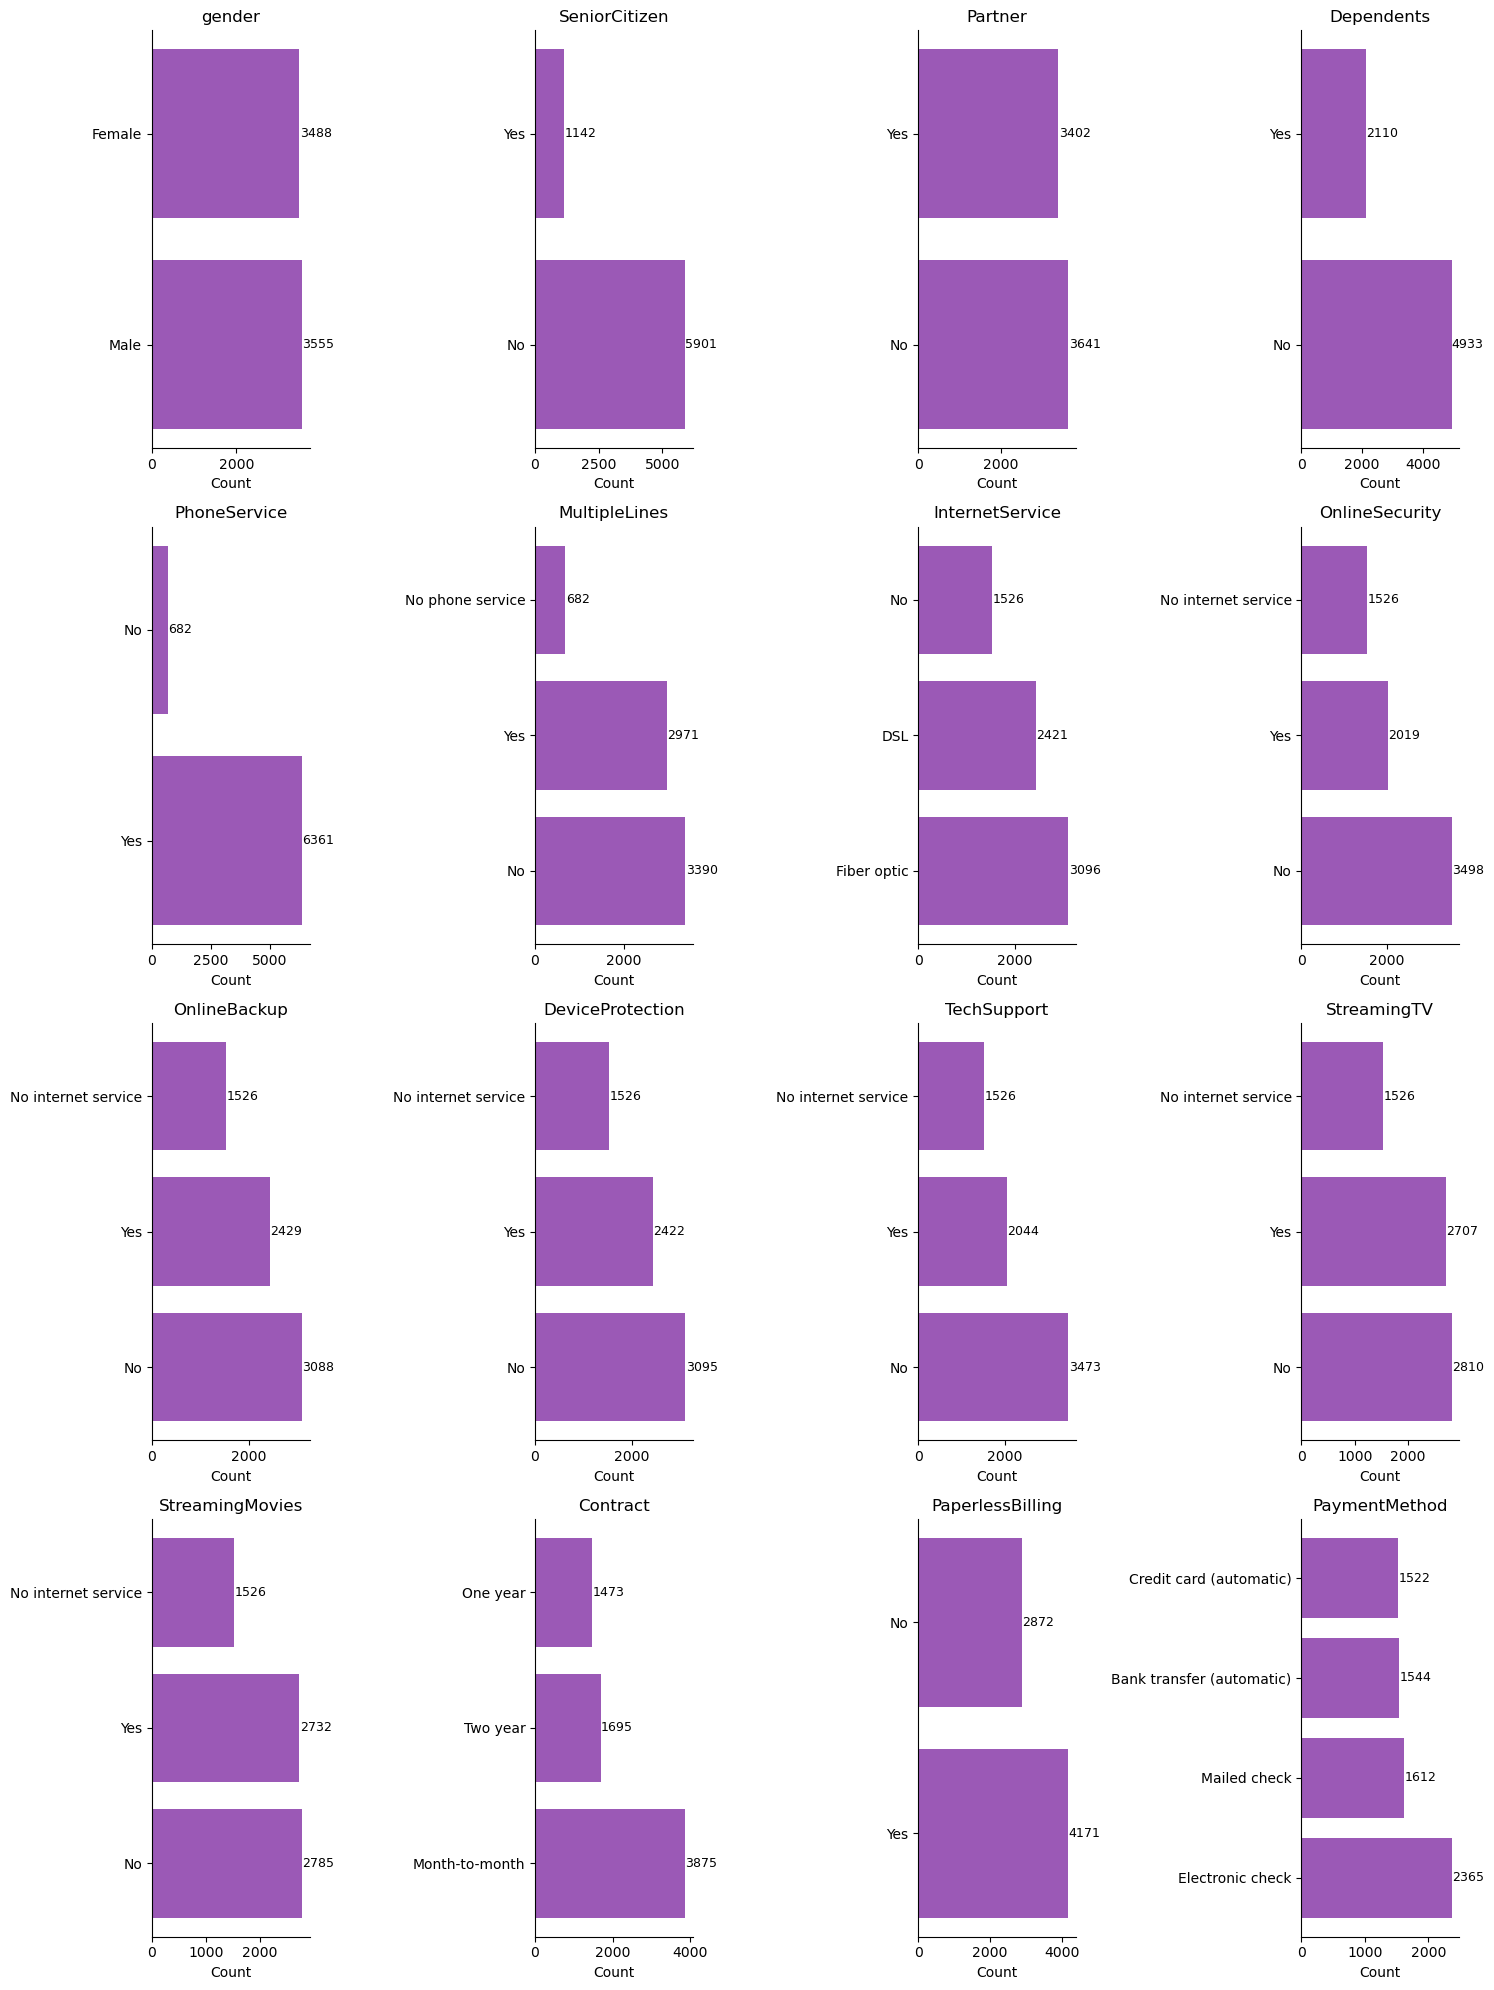

In [19]:
cat_cols_df = df.copy()
cat_cols_df["SeniorCitizen"] = cat_cols_df["SeniorCitizen"].map({0: "No", 1: "Yes"})
cat_cols = cat_cols_df.select_dtypes('object').columns.drop(['customerID', 'Churn', 'TotalCharges']).tolist()

fig, axes = plt.subplots(4, 4, figsize=(15, 20))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    vc = cat_cols_df[col].value_counts() 
    axes[i].barh(vc.index, vc.values, color='#9b59b6')
    axes[i].set_title(col)
    axes[i].set_xlabel('Count')
    for j, (val, cnt) in enumerate(vc.items()):
        axes[i].text(cnt + 10, j, str(cnt), va='center', fontsize=9)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/03_categorical_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Findings from Stage 3
- `tenure` is bimodal: many new customers (tenure ~1) and many long-tenured (tenure ~70).
  This suggests two distinct customer populations. Consider binning as a feature.
- `MonthlyCharges` is roughly uniform, no dominant cluster.
- `TotalCharges` is right-skewed, expected, since it's roughly tenure × MonthlyCharges.
- Q-Q plots confirm none of the numerical features are normally distributed.
  StandardScaler is still appropriate (it doesn't require normality), but
  we should NOT assume normality in any downstream statistical test.
- Several columns (`OnlineSecurity`, `TechSupport`, etc.) have 3 values:
  `Yes`, `No`, `No internet service`. The third category is redundant,
  it duplicates information already in `InternetService`. Will collapse to `No` during cleaning.
- `SeniorCitizen` appears as 0/1 integers. Will treat as binary categorical.

## Stage 4: Bivariate EDA

### Churn rate by each categorical feature

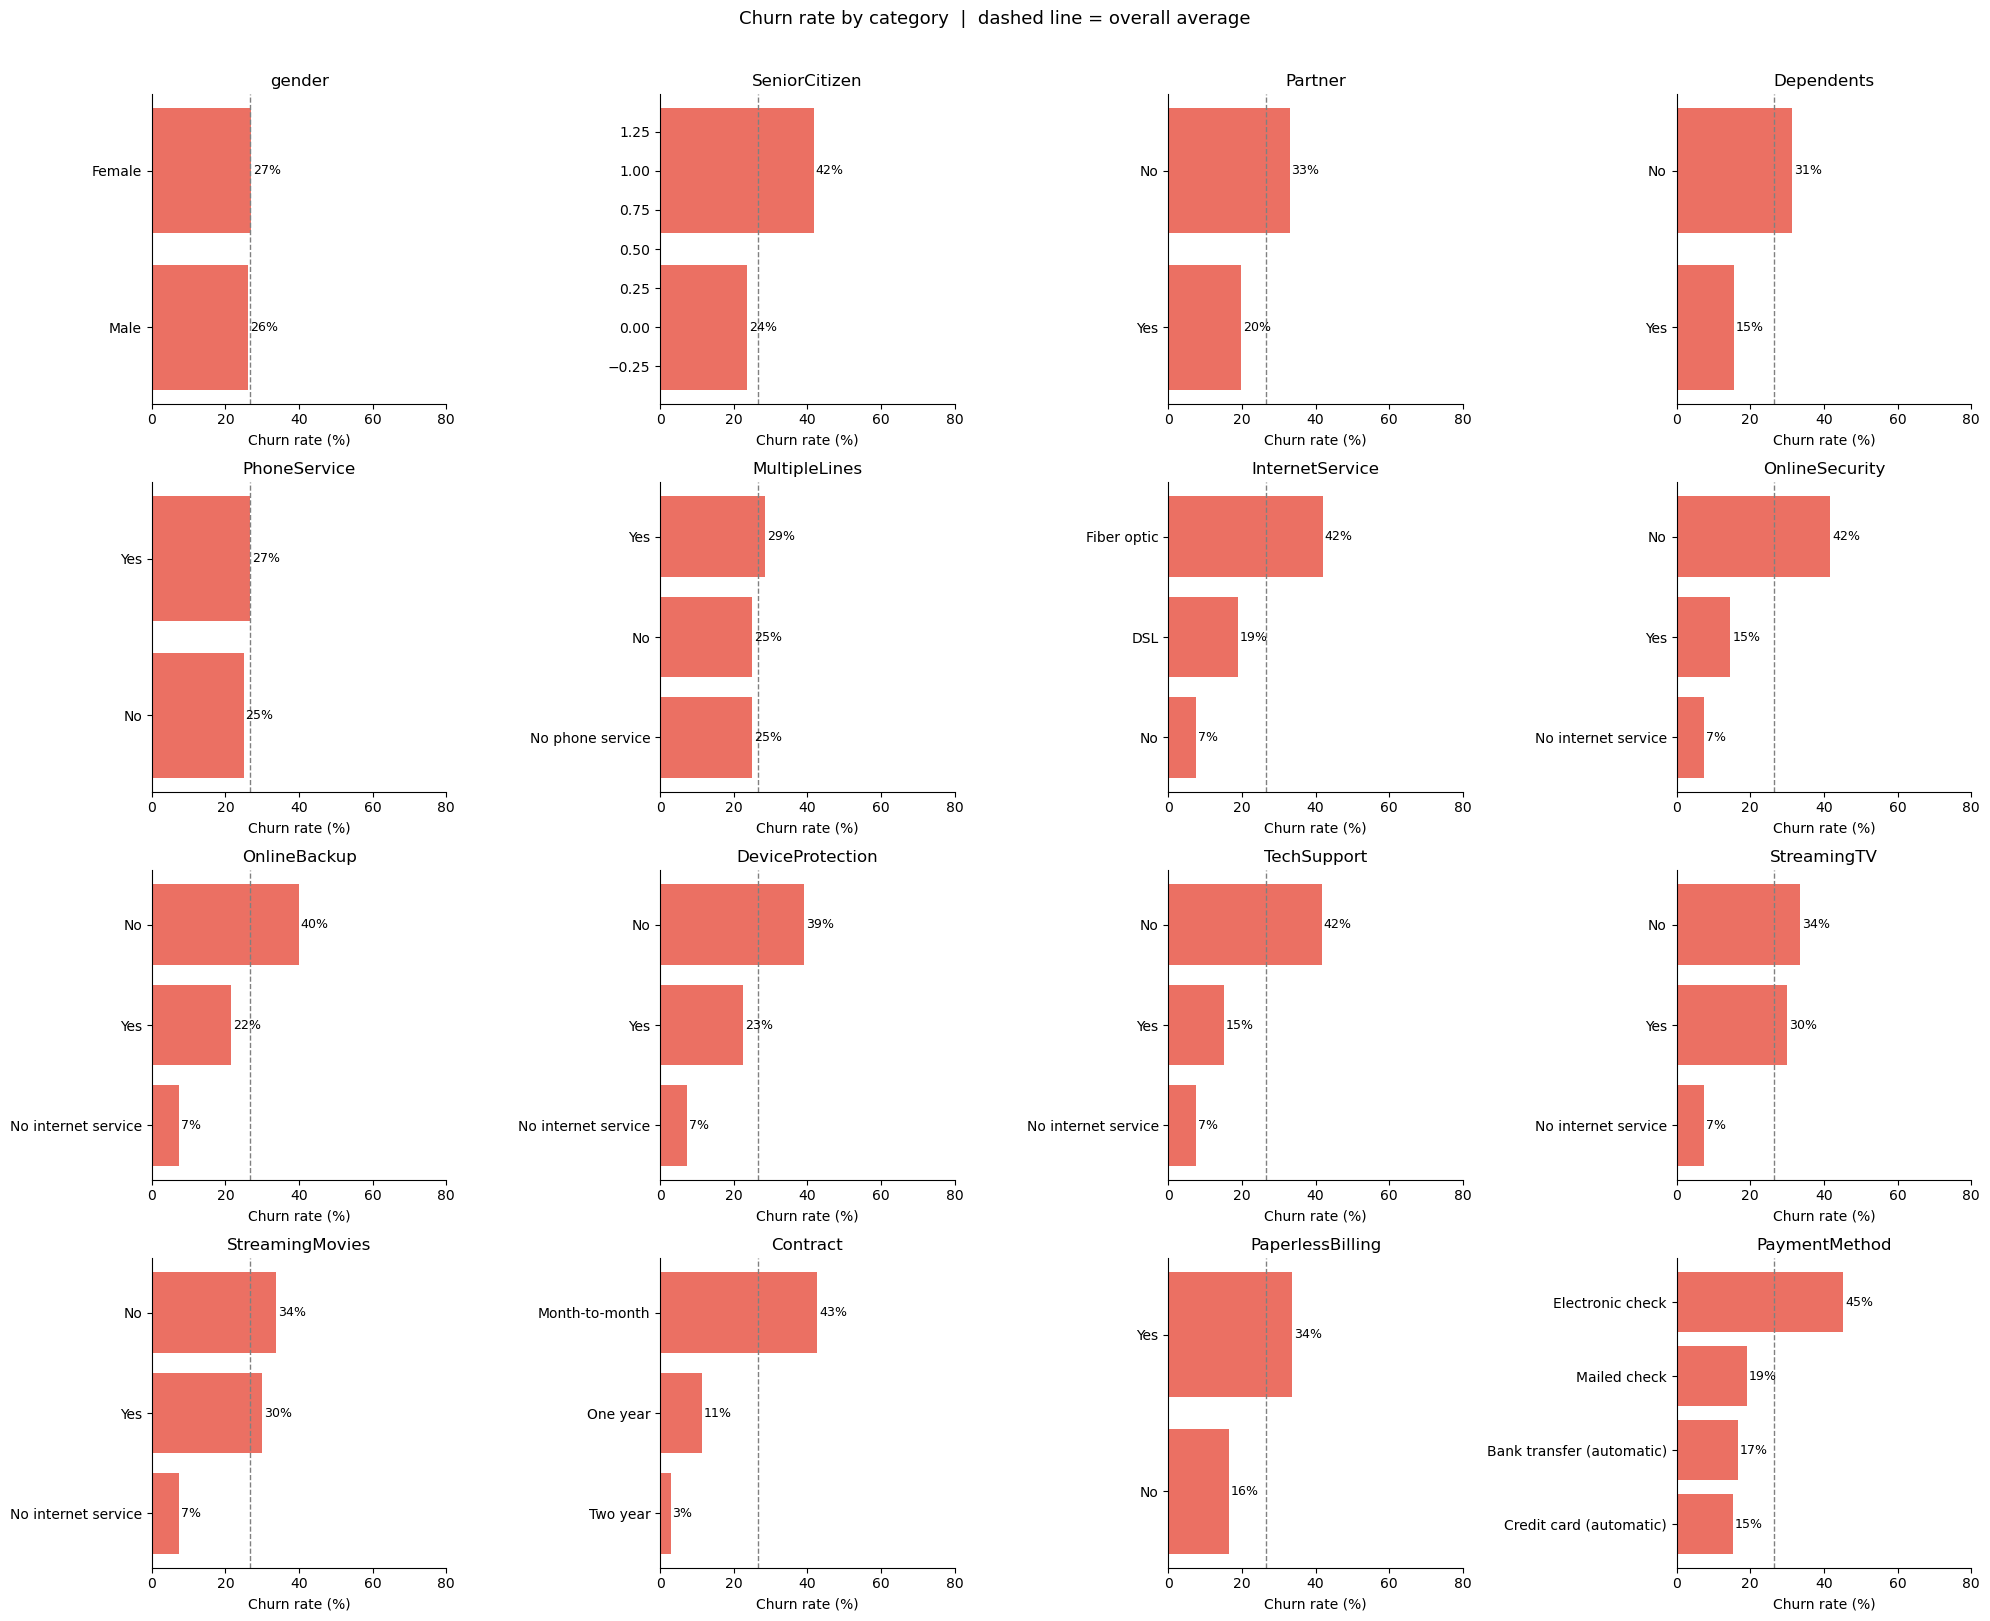

In [20]:
df_biv = df.copy()
df_biv['Churn_binary'] = (df_biv['Churn'] == 'Yes').astype(int)
overall_rate = df_biv['Churn_binary'].mean() * 100

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    rates = df_biv.groupby(col)['Churn_binary'].mean().sort_values() * 100
    bars = axes[i].barh(rates.index, rates.values, color='#e74c3c', alpha=0.8)
    axes[i].axvline(x=overall_rate, color='gray', linestyle='--', linewidth=1)
    axes[i].set_title(f'{col}')
    axes[i].set_xlabel('Churn rate (%)')
    axes[i].set_xlim(0, 80)
    for j, v in enumerate(rates.values):
        axes[i].text(v + 0.5, j, f'{v:.0f}%', va='center', fontsize=9)

for j in range(len(cat_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Churn rate by category  |  dashed line = overall average',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('../reports/04_churn_by_categorical.png', dpi=150, bbox_inches='tight')
plt.show()

### Numerical features vs churn (KDE + Mann-Whitney test)

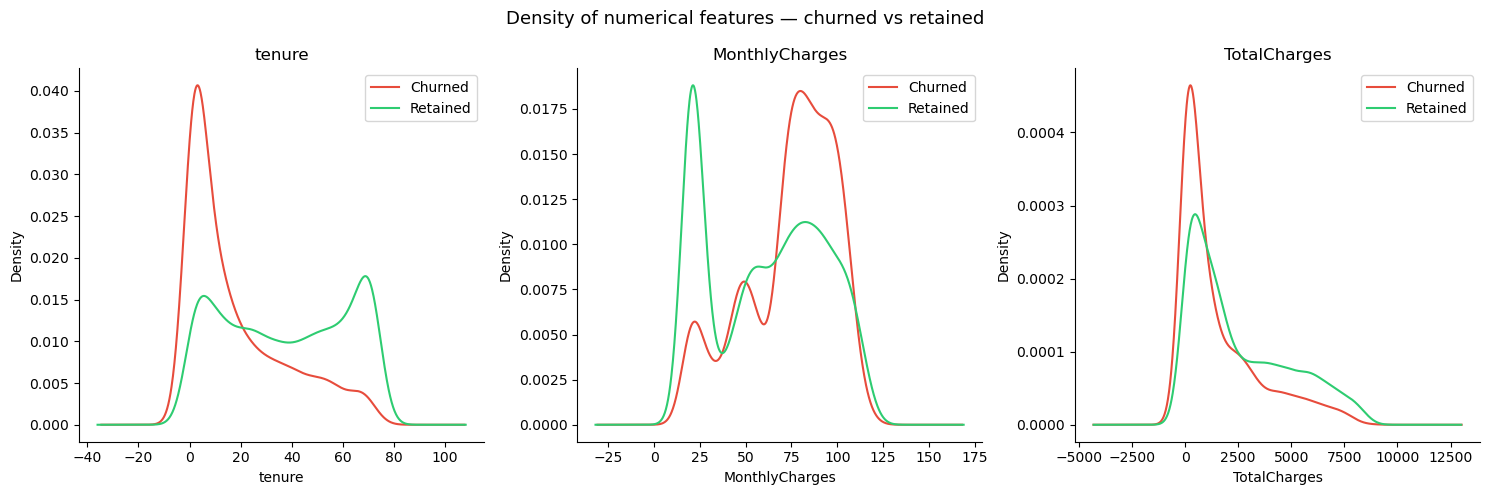

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    churned  = df_plot[df_plot['Churn'] == 'Yes'][col].dropna()
    retained = df_plot[df_plot['Churn'] == 'No'][col].dropna()

    churned.plot.kde(ax=axes[i],  label='Churned',  color='#e74c3c')
    retained.plot.kde(ax=axes[i], label='Retained', color='#2ecc71')
    axes[i].set_title(f'{col}')
    axes[i].legend()
    axes[i].set_xlabel(col)

plt.suptitle('Density of numerical features — churned vs retained', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/05_numerical_vs_churn.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Statistical significance test (non-parametric — no normality assumption)
print("Mann-Whitney U test:")
for col in num_cols:
    churned  = df_plot[df_plot['Churn'] == 'Yes'][col].dropna()
    retained = df_plot[df_plot['Churn'] == 'No'][col].dropna()
    _, p = stats.mannwhitneyu(churned, retained, alternative='two-sided')
    sig = 'significant' if p < 0.05 else 'NOT significant'
    print(f"  {col}: p = {p:.2e}  →  {sig}")

Mann-Whitney U test:
  tenure: p = 2.42e-208  →  significant
  MonthlyCharges: p = 3.31e-54  →  significant
  TotalCharges: p = 2.00e-84  →  significant


### Correlation matrix

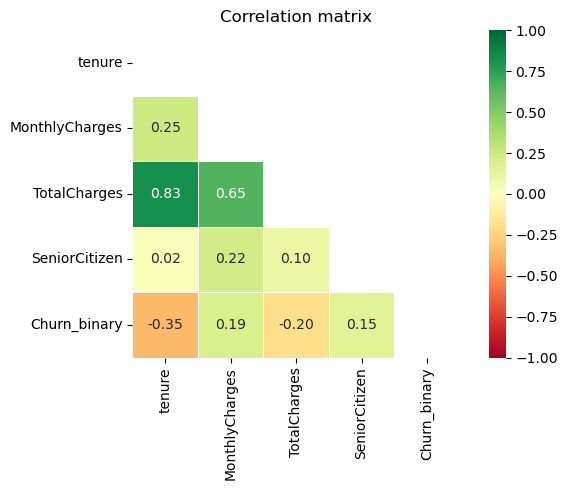

In [23]:
df_corr = df_plot.copy()
df_corr['Churn_binary'] = (df_corr['Churn'] == 'Yes').astype(int)

corr_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen', 'Churn_binary']
corr = df_corr[corr_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))  # hide redundant upper triangle

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            mask=mask, square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation matrix')
plt.tight_layout()
plt.savefig('../reports/06_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Findings from Stage 4
**Strongest predictors of churn (from categorical plot):**
- `Contract`: month-to-month customers churn at ~43% vs 3% for two-year contracts
- `InternetService`: Fiber optic users churn far more than DSL users (~42% vs ~19%)
- `TechSupport`, `OnlineSecurity`: customers without these churn ~2× more
- `PaymentMethod`: electronic check payers churn more than automatic payers

**Numerical features:**
- Churned customers have significantly lower `tenure` (they leave early)
- Churned customers have slightly higher `MonthlyCharges`
- All three numerical features are statistically significant (p << 0.05, Mann-Whitney)

**Multicollinearity alert:**
- `TotalCharges` is highly correlated with `tenure` (r ≈ 0.83) and `MonthlyCharges` (r ≈ 0.65)
- This is expected: TotalCharges ≈ tenure × MonthlyCharges
- For linear models, we may need to drop `TotalCharges` or rely on regularisation.
  Tree-based models are unaffected by multicollinearity.

## Stage 5: Data quality audit

### Missing values

In [24]:
df_audit = df.copy()

print("=== Apparent missing values ===")
print(df_audit.isnull().sum())

# Expose hidden NaNs in TotalCharges
df_audit['TotalCharges'] = pd.to_numeric(df_audit['TotalCharges'], errors='coerce')

print("\n=== After type coercion (hidden NaNs revealed) ===")
missing = df_audit.isnull().sum()
print(missing[missing > 0])

# Inspect the affected rows
mask = df_audit['TotalCharges'].isnull()
print(f"\nAffected rows ({mask.sum()} total):")
print(df_audit[mask][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']])

=== Apparent missing values ===
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

=== After type coercion (hidden NaNs revealed) ===
TotalCharges    11
dtype: int64

Affected rows (11 total):
      customerID  tenure  MonthlyCharges  TotalCharges
488   4472-LVYGI       0           52.55           NaN
753   3115-CZMZD       0           20.25           NaN
936   5709-LVOEQ       0           80.85           NaN
1082  4367-NUYAO       0           25.75           NaN
1340  1371-DWPAZ       0           56.05           NaN
3331  7644-OMVMY       0           19.85           N

### Duplicates

In [25]:
print(f"Fully duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate customerIDs: {df['customerID'].duplicated().sum()}")

Fully duplicate rows: 0
Duplicate customerIDs: 0


### Leakage check

In [26]:
print("=== Leakage audit ===")
print("""
Checking: would each feature exist at prediction time 

customerID     → identifier, not a feature
gender         → YES — known at signup
SeniorCitizen  → YES — known at signup  
Partner        → YES — known at signup
Dependents     → YES — known at signup
tenure         → YES — known at query time
PhoneService   → YES — part of current contract
MultipleLines  → YES — part of current contract
InternetService→ YES — part of current contract
[...all service columns] → YES — current contract details
Contract       → YES — current contract
PaperlessBilling → YES — account setting
PaymentMethod  → YES — account setting
MonthlyCharges → YES — current bill
TotalCharges   → YES — billing history
Churn          → THIS IS THE TARGET

Conclusion: No leakage detected. All features are known before churn happens.
""")

=== Leakage audit ===

Checking: would each feature exist at prediction time 

customerID     → identifier, not a feature
gender         → YES — known at signup
SeniorCitizen  → YES — known at signup  
Partner        → YES — known at signup
Dependents     → YES — known at signup
tenure         → YES — known at query time
PhoneService   → YES — part of current contract
MultipleLines  → YES — part of current contract
InternetService→ YES — part of current contract
[...all service columns] → YES — current contract details
Contract       → YES — current contract
PaperlessBilling → YES — account setting
PaymentMethod  → YES — account setting
MonthlyCharges → YES — current bill
TotalCharges   → YES — billing history
Churn          → THIS IS THE TARGET

Conclusion: No leakage detected. All features are known before churn happens.



### Findings from Stage 5
- `TotalCharges` has 11 hidden missing values caused by whitespace strings, not NaN.
  All 11 affected rows have `tenure = 0` (brand-new customers with no charge yet).
- No duplicate rows or duplicate customerIDs.
- No data leakage: all features are observable before the churn event occurs.
- `SeniorCitizen` is stored as int (0/1) but should be treated as binary categorical.
- Multiple service columns have a third category `"No internet service"` that is
  semantically identical to `"No"` for customers without internet.

## Stage 6 — Data cleaning

### Apply all fixes

In [27]:
df_clean = df.copy()

# 1. Drop identifier — not a feature
df_clean.drop('customerID', axis=1, inplace=True)

# 2. Fix TotalCharges dtype
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# 3. Impute the 11 missing TotalCharges
#    Rationale: tenure=0 means no charges yet. TotalCharges should be 0.
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# 4. Collapse redundant "No internet service" → "No"
service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df_clean[col] = df_clean[col].replace('No internet service', 'No')

df_clean['MultipleLines'] = df_clean['MultipleLines'].replace('No phone service', 'No')

# 5. Encode target to binary
df_clean['Churn'] = (df_clean['Churn'] == 'Yes').astype(int)

print("Cleaning complete.")
print(f"Shape: {df_clean.shape}")
print(f"Remaining nulls: {df_clean.isnull().sum().sum()}")
print(f"Dtypes:\n{df_clean.dtypes}")

Cleaning complete.
Shape: (7043, 20)
Remaining nulls: 0
Dtypes:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object


### Sanity check after cleaning

In [28]:
# Confirm every fix worked as expected
assert df_clean.isnull().sum().sum() == 0, "Still has nulls!"
assert 'customerID' not in df_clean.columns, "customerID not dropped!"
assert df_clean['TotalCharges'].dtype == float, "TotalCharges not float!"
assert set(df_clean['Churn'].unique()) == {0, 1}, "Churn not binary!"

print("All assertions passed. Data is clean.")
df_clean.head()

All assertions passed. Data is clean.


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [30]:
df_clean.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [33]:
df_clean.to_csv("../data/processed/df_clean.csv", index=False)
print("Saved to ../data/processed/df_clean.csv")

Saved to ../data/processed/df_clean.csv


### EDA complete — summary of findings

| Finding | Impact |
|---|---|
| `TotalCharges` had hidden NaN (11 rows, tenure=0) | Imputed to 0 |
| `No internet service` in 6 service columns | Collapsed to `No` |
| `No phone service` in MultipleLines | Collapsed to `No` |
| `customerID` — identifier, not a feature | Dropped |
| Class imbalance: 73.5% No, 26.5% Yes | Use AUC-ROC, not accuracy |
| `TotalCharges` multicollinear with `tenure` | Monitor in linear models |
| `Contract` type is the strongest predictor | Expect high feature importance |